9. ВАРІАНТИ МЕТОДІВ ЗВЕДЕННЯ ДО ЧІТКОСТІ
1. Центр ваги (Centroid): 4.67
2. Бісектриса площі (Bisector): 4.28
3. Середнє з максимумів (MOM): 3.18
4. Найменший з максимумів (SOM): 2.00
5. Найбільший з максимумів (LOM): 7.00



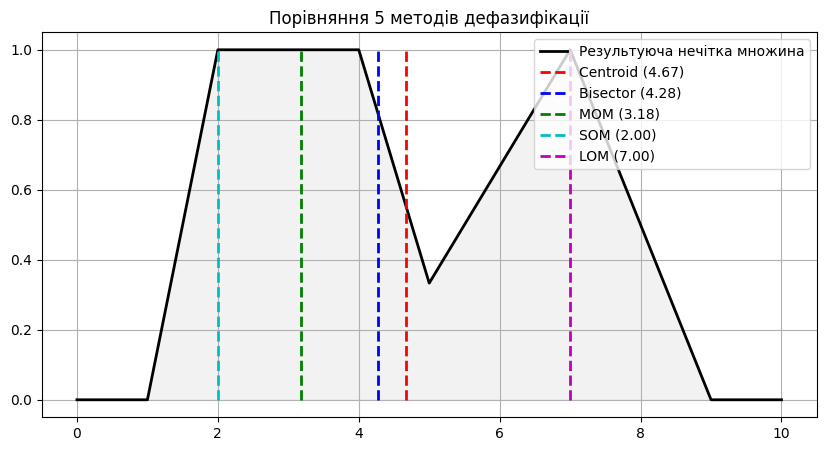

10. БЕЗПЕРЕРВНА (ІНТЕГРАЛ) vs ДИСКРЕТНА (СУМА) ДЕФАЗИФІКАЦІЯ
Інтегрування:
 - Чисельник (Інтеграл x*f(x)): 33.33
 - Знаменник (Інтеграл f(x) - площа): 5.00
 -> Точний Центр ааги: 6.6667

ДИСКРЕТНИЙ МЕТОД:
 -> З грубим кроком (10 точок): 7.0000 (є невелика похибка)
 -> З дрібним кроком (1000 точок): 6.6700
Дискретний метод при достатній кількості точок дає результат, 
ідентичний складному інтегруванню, але працює в рази швидше.


In [4]:
!pip install scikit-fuzzy scipy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import scipy.integrate as integrate

def defuzzification_variants():

    print("9. ВАРІАНТИ МЕТОДІВ ЗВЕДЕННЯ ДО ЧІТКОСТІ")

    x = np.arange(0, 10.1, 0.1)

    #Створюємо складну фігуру, щоб різниця між методами була очевидною
    mfx = fuzz.trapmf(x, [1, 2, 4, 5]) + fuzz.trimf(x, [4, 7, 9])
    #Обмежуємо висоту
    mfx = np.fmin(mfx, 1.0)

    #Розраховуєм 5 різних методів дефазифікації
    cog = fuzz.defuzz(x, mfx, 'centroid')
    bisector = fuzz.defuzz(x, mfx, 'bisector')
    mom = fuzz.defuzz(x, mfx, 'mom')
    som = fuzz.defuzz(x, mfx, 'som')
    lom = fuzz.defuzz(x, mfx, 'lom')

    print(f"1. Центр ваги (Centroid): {cog:.2f}")
    print(f"2. Бісектриса площі (Bisector): {bisector:.2f}")
    print(f"3. Середнє з максимумів (MOM): {mom:.2f}")
    print(f"4. Найменший з максимумів (SOM): {som:.2f}")
    print(f"5. Найбільший з максимумів (LOM): {lom:.2f}\n")

    #Візуалка
    plt.figure(figsize=(10, 5))
    plt.plot(x, mfx, 'k', linewidth=2, label='Результуюча нечітка множина')
    plt.fill_between(x, 0, mfx, alpha=0.1, color='gray')

    #вертикальні лінії для кожного результату
    colors = ['r', 'b', 'g', 'c', 'm']
    methods = [cog, bisector, mom, som, lom]
    labels = ['Centroid', 'Bisector', 'MOM', 'SOM', 'LOM']

    for val, col, lab in zip(methods, colors, labels):
        plt.vlines(val, 0, 1, colors=col, linestyles='dashed', linewidth=2, label=f"{lab} ({val:.2f})")

    plt.title("Порівняння 5 методів дефазифікації")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show(block=False)

def continuous_vs_discrete():

    print("10. БЕЗПЕРЕРВНА (ІНТЕГРАЛ) vs ДИСКРЕТНА (СУМА) ДЕФАЗИФІКАЦІЯ")


    # Сценарій: Простий прямокутний трикутник. Зростає від 0 до 10.
    # Математична функція: f(x) = x / 10
    def f(x):
        return x / 10.0

    def x_times_f(x):
        return x * f(x)

    numerator_integral, _ = integrate.quad(x_times_f, 0, 10)
    denominator_integral, _ = integrate.quad(f, 0, 10)

    continuous_cog = numerator_integral / denominator_integral
    print("Інтегрування:")
    print(f" - Чисельник (Інтеграл x*f(x)): {numerator_integral:.2f}")
    print(f" - Знаменник (Інтеграл f(x) - площа): {denominator_integral:.2f}")
    print(f" -> Точний Центр ааги: {continuous_cog:.4f}\n")


    # Розбиваєм вісь на 10 точок
    x_discrete_rough = np.linspace(0, 10, 11)
    y_discrete_rough = f(x_discrete_rough)

    discrete_cog_rough = np.sum(x_discrete_rough * y_discrete_rough) / np.sum(y_discrete_rough)

    # Розбиваєм вісь на 1000 точок
    x_discrete_fine = np.linspace(0, 10, 1000)
    y_discrete_fine = f(x_discrete_fine)

    discrete_cog_fine = np.sum(x_discrete_fine * y_discrete_fine) / np.sum(y_discrete_fine)

    print("ДИСКРЕТНИЙ МЕТОД:")
    print(f" -> З грубим кроком (10 точок): {discrete_cog_rough:.4f} (є невелика похибка)")
    print(f" -> З дрібним кроком (1000 точок): {discrete_cog_fine:.4f}")
    print("Дискретний метод при достатній кількості точок дає результат, ")
    print("ідентичний складному інтегруванню, але працює в рази швидше.")


if __name__ == "__main__":
    defuzzification_variants()
    continuous_vs_discrete()
    plt.show()